# Crime Data Analysis — Los Angeles (2020–2024)
**Phase:** Data Understanding  
**Dataset:** 1,004,894 records · 28 features  
**Source:** [data.gov — Crime Data from 2020 to Present](http://catalog.data.gov/dataset/crime-data-from-2020-to-present)

---

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

DATA_PATH = os.getenv("DATA_PATH")

pd.set_option('display.max_columns', None)
file_path = Path(DATA_PATH) / "Crime_Data_from_2020_to_2024.csv" # type: ignore
df = pd.read_csv(file_path)

## 2. First Look at the Data

Getting a quick overview: shape, first rows, dtypes, and basic stats.

In [3]:
df.shape

(1004894, 28)

In [4]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,31,M,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,32,M,H,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,30,M,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,47,F,A,101.0,STREET,NaN,NaN,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,63,M,H,103.0,ALLEY,NaN,NaN,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

In [6]:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004878e+06,327216.000000,1.004883e+06,69154.000000,2314.000000,64.00000,1.004894e+06,1.004894e+06
mean,2.202190e+08,1.339901e+03,1.069153e+01,1.115613e+03,1.400313e+00,5.001386e+02,2.891862e+01,3.056108e+02,363.950797,4.998992e+02,958.097796,984.015990,991.21875,3.399820e+01,-1.180908e+02
std,1.319070e+07,6.510761e+02,6.110248e+00,6.111596e+02,4.899620e-01,2.052638e+02,2.199267e+01,2.192913e+02,123.737665,2.050643e+02,110.358509,52.350982,27.06985,1.610789e+00,5.582654e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106168e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209158e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311102e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521040e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


## 3. Missing Values

Understanding which columns have nulls and how severe the missingness is.

In [7]:
df.isna().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151598
Vict Age                0
Vict Sex           144631
Vict Descent       144643
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677678
Weapon Desc        677678
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935740
Crm Cd 3          1002580
Crm Cd 4          1004830
LOCATION                0
Cross Street       850666
LAT                     0
LON                     0
dtype: int64

**Observations:**
- `Mocodes`: ~151K nulls — not all crimes have recorded MO codes.
- `Vict Sex` / `Vict Descent`: ~144K nulls — missing victim demographics (likely property crimes with no direct victim).
- `Weapon Used Cd` / `Weapon Desc`: ~677K nulls — ~67% missing; most crimes don't involve a recorded weapon.
- `Cross Street`: ~850K nulls — only intersection-based crimes fill this.
- `Crm Cd 2/3/4`: Sparse by design — most crimes have only one charge.

## 4. Column-by-Column Exploration

In [8]:
df['TIME OCC'].value_counts()

TIME OCC
1200    35198
1800    26573
1700    25189
2000    24779
1900    23074
        ...  
741        29
534        26
2332       26
559        23
531        19
Name: count, Length: 1439, dtype: int64

### 4.2 Geographic Division — `AREA` & `AREA NAME`

LA is divided into **21 policing areas**. `AREA` is the numeric code, `AREA NAME` is its label.  
Each area is further sub-divided into reporting districts (`Rpt Dist No`) for granular mapping.

In [9]:
print(df['AREA'].nunique(), 'unique areas')
df['AREA NAME'].unique()

21 unique areas


array(['N Hollywood', 'Van Nuys', 'Wilshire', 'Pacific', 'Hollenbeck',
       'Southwest', 'Northeast', 'Devonshire', 'Topanga', 'Hollywood',
       'Olympic', 'Southeast', 'Newton', 'Foothill', 'Mission', 'Rampart',
       'Central', 'West LA', '77th Street', 'West Valley', 'Harbor'],
      dtype=object)

In [28]:
def display_all_unique_areas(df):
    for area in sorted(df['AREA'].unique()):
        area_name = df[df['AREA'] == area]['AREA NAME'].unique()
        print(f"Area {area}: {area_name[0]}")

display_all_unique_areas(df)

Area 1: Central
Area 2: Rampart
Area 3: Southwest
Area 4: Hollenbeck
Area 5: Harbor
Area 6: Hollywood
Area 7: Wilshire
Area 8: West LA
Area 9: Van Nuys
Area 10: West Valley
Area 11: Northeast
Area 12: 77th Street
Area 13: Newton
Area 14: Pacific
Area 15: N Hollywood
Area 16: Foothill
Area 17: Devonshire
Area 18: Southeast
Area 19: Mission
Area 20: Olympic
Area 21: Topanga


In [11]:
df.groupby('AREA NAME')['Rpt Dist No'].nunique().sort_values(ascending=False)

AREA NAME
Pacific        75
Devonshire     74
West LA        70
Foothill       68
Wilshire       66
Mission        65
Northeast      65
N Hollywood    63
Hollenbeck     63
West Valley    62
Southwest      58
Van Nuys       57
Rampart        54
Central        53
Olympic        53
Topanga        53
Harbor         51
Newton         45
Hollywood      41
77th Street    40
Southeast      34
Name: Rpt Dist No, dtype: int64

### 4.3 Crime Classification — `Part 1-2`, `Crm Cd`, `Crm Cd Desc`

- **Part 1** = serious crimes (Homicide, Rape, Robbery, Burglary, etc.)
- **Part 2** = less serious (Simple Assault, Fraud, Drug Offenses, Vandalism, etc.)
- `Crm Cd` is the LAPD numeric crime code; `Crm Cd Desc` is its human-readable label.  
  Each code maps to exactly one description (1-to-1 relationship).

In [12]:
df['Part 1-2'].value_counts()

Part 1-2
1    602622
2    402272
Name: count, dtype: int64

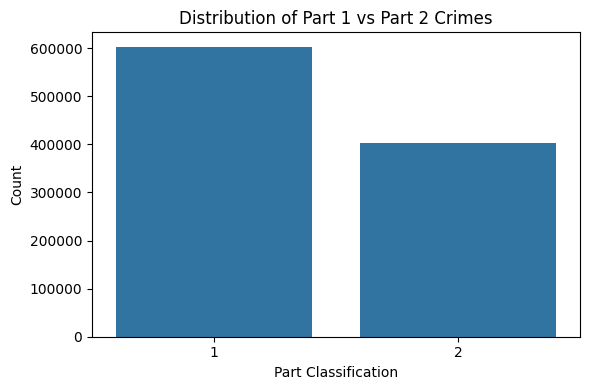

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Part 1-2')
plt.title('Distribution of Part 1 vs Part 2 Crimes')
plt.xlabel('Part Classification')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [14]:
print(f"Unique crime codes:        {df['Crm Cd'].nunique()}")
print(f"Unique crime descriptions: {df['Crm Cd Desc'].nunique()}")
# Confirmed: each code maps to exactly one description

Unique crime codes:        140
Unique crime descriptions: 140


In [15]:
df['Crm Cd'].value_counts().head(10)

Crm Cd
510    115184
624     74821
330     63515
354     62536
740     61086
310     57871
440     53716
230     53523
626     46712
420     41311
Name: count, dtype: int64

### 4.4 Victim Information — `Vict Age`, `Vict Sex`, `Vict Descent`

These three columns describe the victim's demographics.  
**Known data quality issues:**
- ~25% of `Vict Age` values are **0** — likely used as a placeholder for unknown/no victim.
- **137 rows** have **negative ages** — impossible values to be handled in cleaning.

In [16]:
print(f"Unique ages: {df['Vict Age'].nunique()}")
df['Vict Age'].value_counts().head(10)

Unique ages: 104


Vict Age
0     269178
30     22288
35     21832
31     21419
29     21343
28     20969
32     20843
33     20361
27     20129
34     19419
Name: count, dtype: int64

In [17]:
print(f"Rows with age == 0:  {(df['Vict Age'] == 0).sum()}")
print(f"Rows with age < 0:   {(df['Vict Age'] < 0).sum()}")

Rows with age == 0:  269178
Rows with age < 0:   137


In [18]:
print(df['Vict Sex'].value_counts())
print()
print("As percentages:")
print((df['Vict Sex'].value_counts(normalize=True) * 100).round(2))

Vict Sex
M    403842
F    358553
X     97753
H       114
-         1
Name: count, dtype: int64

As percentages:
Vict Sex
M    46.94
F    41.68
X    11.36
H     0.01
-     0.00
Name: proportion, dtype: float64


**Victim Descent codes:**

| Code | Descent |
|------|---------|
| A | Other Asian |
| B | Black |
| C | Chinese |
| H | Hispanic/Latin/Mexican |
| W | White |
| O | Other |
| X | Unknown |
| ... | (see full table in columns.txt) |

In [19]:
print(f"Unique descent codes: {df['Vict Descent'].nunique()}")
df['Vict Descent'].value_counts()

Unique descent codes: 20


Vict Descent
H    296370
W    201429
B    135809
X    106661
O     78001
A     21338
K      5990
F      4838
C      4631
J      1586
V      1195
I      1015
Z       577
P       288
U       221
D        91
L        77
G        74
S        58
-         2
Name: count, dtype: int64

### 4.5 Premises — `Premis Cd` & `Premis Desc`

Numeric code + description for the **type of location** where the crime occurred  
(e.g., 101 = Street, 501 = Single Family Dwelling, 108 = Parking Lot).

In [20]:
print(f"Unique premise codes: {df['Premis Cd'].nunique()}")
df['Premis Desc'].value_counts().head(10)

Unique premise codes: 314


Premis Desc
STREET                                          261261
SINGLE FAMILY DWELLING                          163650
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    119010
PARKING LOT                                      69142
OTHER BUSINESS                                   47646
SIDEWALK                                         40861
VEHICLE, PASSENGER/TRUCK                         29300
GARAGE/CARPORT                                   19362
DRIVEWAY                                         16081
DEPARTMENT STORE                                 14433
Name: count, dtype: int64

### 4.6 Weapon — `Weapon Used Cd` & `Weapon Desc`

Numeric code + description of the weapon used.  
**~67% of rows are null** — most crimes either had no weapon or it wasn't identified.  
This high missingness limits weapon-focused analysis but is expected for theft/fraud-type crimes.

In [21]:
print(f"Missing weapon data: {df['Weapon Desc'].isna().sum() / len(df) * 100:.1f}%")
df['Weapon Desc'].value_counts().head(10)

Missing weapon data: 67.4%


Weapon Desc
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    174739
UNKNOWN WEAPON/OTHER WEAPON                        36387
VERBAL THREAT                                      23842
HAND GUN                                           20182
SEMI-AUTOMATIC PISTOL                               7267
KNIFE WITH BLADE 6INCHES OR LESS                    6837
UNKNOWN FIREARM                                     6582
OTHER KNIFE                                         5879
MACE/PEPPER SPRAY                                   3730
VEHICLE                                             3260
Name: count, dtype: int64

### 4.7 Case Status — `Status` & `Status Desc`

Tracks the current investigation/arrest status of each crime report.

| Code | Description |
|------|-------------|
| IC   | Investigation Continued |
| AA   | Adult Arrest |
| AO   | Adult Other |
| JA   | Juvenile Arrest |
| JO   | Juvenile Other |
| CC   | UNK |

In [22]:
print(df['Status'].value_counts())
print(f"\nNull status rows: {df['Status'].isna().sum()}")

Status
IC    802772
AO    109799
AA     87152
JA      3285
JO      1879
CC         6
Name: count, dtype: int64

Null status rows: 1


### 4.8 Secondary Crime Codes — `Crm Cd 1`, `Crm Cd 2`, `Crm Cd 3`, `Crm Cd 4`

A single incident can involve multiple charges.  
`Crm Cd 1` is the **primary charge** (nearly complete); codes 2–4 are supplementary and increasingly sparse.

In [23]:
print(f"Crm Cd 1 non-null: {df['Crm Cd 1'].count():>8,}")
print(f"Crm Cd 2 non-null: {df['Crm Cd 2'].count():>8,}")
print(f"Crm Cd 3 non-null: {df['Crm Cd 3'].count():>8,}")
print(f"Crm Cd 4 non-null: {df['Crm Cd 4'].count():>8,}")

Crm Cd 1 non-null: 1,004,883
Crm Cd 2 non-null:   69,154
Crm Cd 3 non-null:    2,314
Crm Cd 4 non-null:       64


In [24]:
df[df['Crm Cd 2'].notna()].sample(1)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
475138,220416792,12/30/2022 12:00:00 AM,12/29/2022 12:00:00 AM,2330,4,Hollenbeck,442,1,510,VEHICLE - STOLEN,2004 0344 1300 0358 1402,53,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,998.0,NaN,NaN,MISSION RD,GALLARDO,34.0557,-118.2227


### 4.9 MO Codes — `Mocodes`

Space-separated numeric codes describing **how** the crime was committed.  
A single crime can have multiple MO codes. Requires a separate lookup table for interpretation.

In [25]:
print(f"Unique MO code combinations: {df['Mocodes'].nunique()}")

Unique MO code combinations: 310912


### 4.10 Location Columns — `LOCATION`, `Cross Street`, `LAT`, `LON`

- `LOCATION`: Street address (anonymized to block level for privacy).
- `Cross Street`: Only populated for intersection-based crimes (~15% of records).
- `LAT` / `LON`: Geographic coordinates — useful for spatial analysis and mapping.

In [26]:
print(f"Unique locations:     {df['LOCATION'].nunique():,}")
print(f"Unique cross streets: {df['Cross Street'].nunique():,}")
print(f"Cross street coverage: {df['Cross Street'].notna().sum() / len(df) * 100:.1f}%")

Unique locations:     66,566
Unique cross streets: 10,413
Cross street coverage: 15.3%


In [27]:
df[df['Cross Street'].notna()].sample(3)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
839322,231224286,12/03/2023 12:00:00 AM,12/03/2023 12:00:00 AM,2110,12,77th Street,1218,1,210,ROBBERY,0342 1240 1309 1311 0448 0416 0355 0344 0326,43,M,H,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,210.0,NaN,NaN,NaN,FIGUEROA ST,55TH ST,33.9924,-118.2827
26846,201713884,10/03/2020 12:00:00 AM,10/01/2020 12:00:00 AM,1100,17,Devonshire,1721,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,TOPANGA CANYON,CHATSWORTH,34.2645,-118.6061
174463,201111482,07/16/2020 12:00:00 AM,07/15/2020 12:00:00 AM,1015,11,Northeast,1133,2,624,BATTERY - SIMPLE ASSAULT,0400 0416 1822 0444 1202,70,F,H,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,624.0,NaN,NaN,NaN,LARGA,FLETCHER,34.1111,-118.2522


## 5. Summary of Key Findings

| Finding | Detail |
|---------|--------|
| Dataset size | 1,004,894 rows × 28 columns |
| Time range | 2020–2024 |
| Crime severity split | Part 1 (~60%) vs Part 2 (~40%) |
| Victim age anomalies | ~250K rows with age = 0; 137 rows with negative age |
| Weapon data missing | ~67% — expected for non-violent crimes |
| Secondary crime codes | Very sparse (Crm Cd 2–4 used rarely) |
| Geospatial coverage | Full LAT/LON for all records |
| Key columns to rename | `Date Rptd`, `DATE OCC`, `TIME OCC` |

---

## Next Steps

- **Data Cleaning:** Handle age anomalies, rename columns, parse datetime formats, address missing values
- **EDA:** Temporal trends, geographic hotspots, crime type distributions, victim demographics

---
*Made by Youssef Moussa — [GitHub](https://github.com/theyoussefmoussa) · [LinkedIn](https://www.linkedin.com/in/theyoussefmoussa/)*